# Danish Vehicle Registration — Time Series Plot

Training data: 2018-Jan to 2023-Dec (total registered vehicles vs. decimal year).

In [14]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1

In [15]:
# Read CSV and filter for training period (2018-Jan to 2023-Dec)
df = pd.read_csv("DST_BIL54.csv")
df["time"] = pd.to_datetime(df["time"], format="%Y-%m")

start = pd.Timestamp("2018-01-01")
end = pd.Timestamp("2023-12-01")
train = df[(df["time"] >= start) & (df["time"] <= end)].copy()

# Create time variable x as decimal year: 2018-Jan -> 2018.0, 2018-Feb -> 2018 + 1/12, ...
# Formula: x = year + (month - 1) / 12
train["x"] = train["time"].dt.year + (train["time"].dt.month - 1) / 12

# Use total (number of registered vehicles) and x for plotting
x = train["x"].values
total = train["total"].values
print(f"Training period: {train['time'].min().strftime('%Y-%b')} to {train['time'].max().strftime('%Y-%b')} ({len(train)} months)")
train[["time", "x", "total"]].head(12)

Training period: 2018-Jan to 2023-Dec (72 months)


,time,x,total
0,2018-01-01,2018.000000,2930483
1,2018-02-01,2018.083333,2934044
2,2018-03-01,2018.166667,2941422
3,2018-04-01,2018.250000,2951498
4,2018-05-01,2018.333333,2963093
5,2018-06-01,2018.416667,2973721
6,2018-07-01,2018.500000,2976096
7,2018-08-01,2018.583333,2985537
8,2018-09-01,2018.666667,2983209
9,2018-10-01,2018.750000,2982473


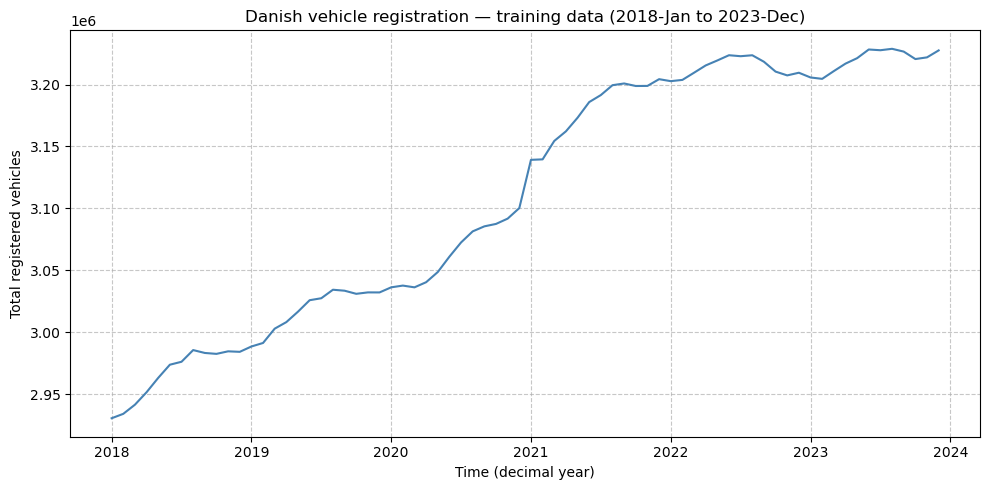

In [16]:
# Time series plot: total registered vehicles vs. decimal year x
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, total, color="steelblue", linewidth=1.5)
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("Total registered vehicles")
ax.set_title("Danish vehicle registration — training data (2018-Jan to 2023-Dec)")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Total Registered Vehicles is increasing troughout the entire period from 2018-2024

# 2

In [17]:
# print first 3 time points in train
print(train.head(3))

        time    total  gasoline   diesel  fgas  ngas  electricity  petroleum  \
0 2018-01-01  2930483   1781826  1136656    12   256         9304          0   
1 2018-02-01  2934044   1783338  1138414    12   255         9343          0   
2 2018-03-01  2941422   1787219  1141576    12   257         9399          0   

   hydrogen  methanol  ethanol  pluginhybrid  otherfuels            x  
0        81         0        0          2340           8  2018.000000  
1        80         0        0          2593           9  2018.083333  
2        77         0        0          2873           9  2018.166667  


# 3

In [18]:
# Estimate θ₁ and θ₂ by OLS: θ̂ = (X'X)^{-1} X'y
# Full training set: design matrix X (column of 1s, column of x) and output y (total)
N = len(train)
ones = np.ones(N)
x_vals = train["x"].values
y_vals = train["total"].values

X = np.column_stack([ones, x_vals])  # N x 2
y = y_vals.reshape(-1, 1)           # N x 1

# OLS: θ̂ = (X'X)^{-1} X'y
XtX = X.T @ X
Xty = X.T @ y
theta_hat = np.linalg.solve(XtX, Xty)

theta1 = theta_hat[0, 0]   # intercept
theta2 = theta_hat[1, 0]   # slope (vehicles per year)

print("Linear trend model: Y_t = θ₁ + θ₂·x_t + ε_t")
print(f"Estimated θ₁ (intercept): {theta1:,.2f}")
print(f"Estimated θ₂ (slope):    {theta2:,.2f}")
print(f"\nInterpretation: total ≈ {theta1:,.0f} + {theta2:,.0f} × (decimal year)")

Linear trend model: Y_t = θ₁ + θ₂·x_t + ε_t
Estimated θ₁ (intercept): -110,355,428.09
Estimated θ₂ (slope):    56,144.56

Interpretation: total ≈ -110,355,428 + 56,145 × (decimal year)


Parameter estimates and estimated standard errors:
──────────────────────────────────────────────────
  θ̂₁ = -110,355,428.09   σ̂_θ̂₁ = 3,593,581.12
  θ̂₂ =      56,144.56   σ̂_θ̂₂ =     1,778.16
──────────────────────────────────────────────────


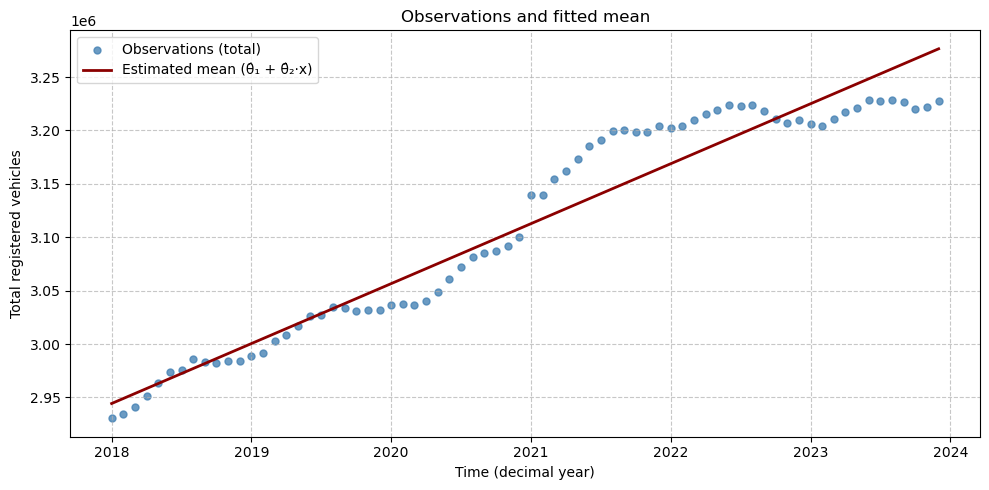

In [20]:
# Standard errors: σ̂² = RSS/(N-p), Cov(θ̂) = σ̂² (X'X)^{-1}, SE(θ̂_j) = sqrt(Cov(θ̂)_jj)
p = 2
y_fitted = X @ theta_hat
residuals = y - y_fitted
RSS = (residuals ** 2).sum()
sigma2_hat = RSS / (N - p)
XtX_inv = np.linalg.inv(XtX)
cov_theta = sigma2_hat * XtX_inv
se_theta1 = np.sqrt(cov_theta[0, 0])
se_theta2 = np.sqrt(cov_theta[1, 1])

print("Parameter estimates and estimated standard errors:")
print("─" * 50)
print(f"  θ̂₁ = {theta1:>14,.2f}   σ̂_θ̂₁ = {se_theta1:>12,.2f}")
print(f"  θ̂₂ = {theta2:>14,.2f}   σ̂_θ̂₂ = {se_theta2:>12,.2f}")
print("─" * 50)

# Plot: observations as points, estimated mean as line
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_vals, y_vals, color="steelblue", s=25, alpha=0.8, label="Observations (total)")
ax.plot(x_vals, y_fitted, color="darkred", linewidth=2, label="Estimated mean (θ̂₁ + θ̂₂·x)")
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("Total registered vehicles")
ax.set_title("Observations and fitted mean")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
# Forecast for test set: 2024-Jan to 2024-Dec (12 months)
# Point forecast: ŷ = θ̂₁ + θ̂₂·x
# 95% prediction interval: ŷ ± t_{N-2, 0.975} × SE_pred, with SE_pred = σ̂ × sqrt(1 + x_new'(X'X)^{-1} x_new)
from scipy import stats

# Test period: 12 months from 2024-Jan to 2024-Dec
test_months = pd.date_range("2024-01-01", periods=12, freq="MS")
x_test = np.array([2024 + (i - 1) / 12 for i in range(1, 13)])  # 2024.0, 2024.083, ..., 2024.917
X_test = np.column_stack([np.ones(12), x_test])

# Point forecasts
y_pred = (X_test @ theta_hat).flatten()

# Prediction standard error: SE_pred_t = σ̂ × sqrt(1 + x_t'(X'X)^{-1} x_t)
sigma_hat = np.sqrt(sigma2_hat)
se_pred = np.array([
    sigma_hat * np.sqrt(1 + X_test[i : i + 1] @ XtX_inv @ X_test[i : i + 1].T).item()
    for i in range(12)
])

# 95% prediction interval (t with N-2 df)
t_crit = stats.t.ppf(0.975, N - p)
lower = y_pred - t_crit * se_pred
upper = y_pred + t_crit * se_pred

# Table: Month, x, Predicted, Lower 95% PI, Upper 95% PI
forecast_df = pd.DataFrame({
    "Month": [d.strftime("%Y-%b") for d in test_months],
    "x": np.round(x_test, 3),
    "Predicted": np.round(y_pred, 0),
    "Lower 95% PI": np.round(lower, 0),
    "Upper 95% PI": np.round(upper, 0),
})
print("Forecasts and 95% prediction intervals (test set: 2024-Jan to 2024-Dec)\n")
display(forecast_df)

Forecasts and 95% prediction intervals (test set: 2024-Jan to 2024-Dec)



,Month,x,Predicted,Lower 95% PI,Upper 95% PI
0,2024-Jan,2024.000,3281154.0,3227579.0,3334728.0
1,2024-Feb,2024.083,3285832.0,3232198.0,3339467.0
2,2024-Mar,2024.167,3290511.0,3236815.0,3344208.0
3,2024-Apr,2024.250,3295190.0,3241430.0,3348950.0
4,2024-May,2024.333,3299869.0,3246044.0,3353693.0
5,2024-Jun,2024.417,3304547.0,3250656.0,3358439.0
6,2024-Jul,2024.500,3309226.0,3255267.0,3363185.0
7,2024-Aug,2024.583,3313905.0,3259876.0,3367934.0
8,2024-Sep,2024.667,3318583.0,3264483.0,3372683.0
9,2024-Oct,2024.750,3323262.0,3269090.0,3377435.0


In [ ]:
# Combined plot: training data, fitted model, forecasts, and 95% prediction intervals
fig, ax = plt.subplots(figsize=(12, 6))

# Training data
ax.scatter(x_vals, y_vals, color="steelblue", s=25, alpha=0.8, label="Training data")

# Fitted line (training range)
ax.plot(x_vals, y_fitted, color="darkred", linewidth=2, label="Fitted model (θ̂₁ + θ̂₂·x)")

# Forecast period: extend fitted line and show forecast points
ax.plot(x_test, y_pred, color="darkgreen", linewidth=2, linestyle="-", marker="o", markersize=5, label="Forecast")

# 95% prediction interval (shaded band)
ax.fill_between(x_test, lower, upper, color="darkgreen", alpha=0.2, label="95% prediction interval")

ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("Total registered vehicles")
ax.set_title("Fitted model, training data, forecasts and 95% prediction intervals")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()